## Week 2 - Day 4 - EDA Part 1: Distributions & Outliers

BinX Tech AI & ML Internship

Topics:
- Why EDA comes before modeling
- Seaborn for statistical visualization
- Univariate analysis: histogram, box plot, count plot, KDE
- Outlier detection with the IQR method

The parts under here are for testing and showcasing the lesson content, and the Day 4 task will be at the end.

## Univariate Plots

A quick demo of each plot type on a small synthetic sample before using them for real on the lab dataset.

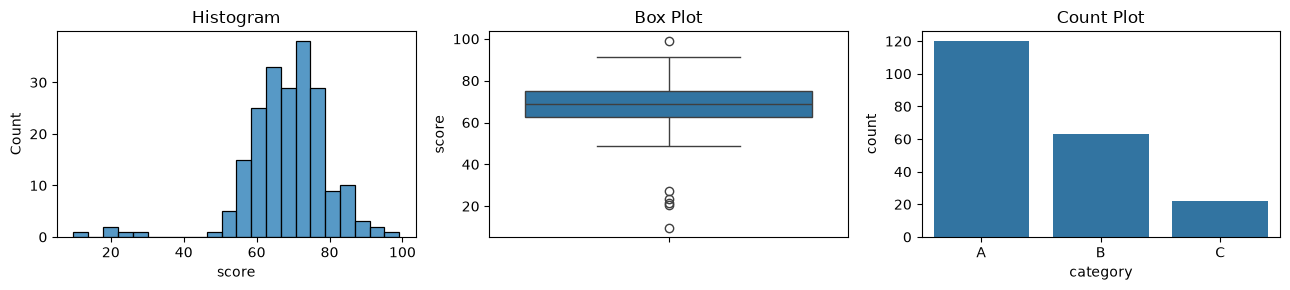

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
demo = pd.DataFrame({
    "score": np.concatenate([rng.normal(70, 10, 200), rng.normal(20, 5, 5)]),  # a few outliers
    "category": rng.choice(["A", "B", "C"], size=205, p=[0.6, 0.3, 0.1])
})

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
sns.histplot(data=demo, x="score", ax=axes[0])
axes[0].set_title("Histogram")
sns.boxplot(data=demo, y="score", ax=axes[1])
axes[1].set_title("Box Plot")
sns.countplot(data=demo, x="category", ax=axes[2])
axes[2].set_title("Count Plot")
plt.tight_layout()
plt.show()

## IQR Outlier Detection

In [3]:
Q1 = demo["score"].quantile(0.25)
Q3 = demo["score"].quantile(0.75)
IQR = Q3 - Q1

outliers = demo[(demo["score"] < Q1 - 1.5 * IQR) | (demo["score"] > Q3 + 1.5 * IQR)]
print(f"Found {len(outliers)} outliers out of {len(demo)} rows")
outliers

Found 6 outliers out of 205 rows


,score,category
139,99.138625,A
200,21.687873,C
201,27.037409,B
202,20.452925,B
203,23.219694,A
204,9.749139,B


## Day 4 Tasks

Now everything under here is for the hands-on lab, using the IMDb Top 1000 dataset.

## Step 0 - Load and Clean

`Runtime` and `Gross` are stored as text (e.g. "142 min", "28,341,469"), so they need cleaning into numeric
columns before they can be plotted or analyzed.

In [4]:
imdb = pd.read_csv("../imdb_top_1000.csv")

imdb["Runtime_Minutes"] = imdb["Runtime"].str.replace(" min", "", regex=False).astype(float)
imdb["Gross_Clean"] = imdb["Gross"].str.replace(",", "", regex=False).astype(float)

numeric_cols = ["IMDB_Rating", "Meta_score", "No_of_Votes", "Runtime_Minutes", "Gross_Clean"]
imdb[numeric_cols].describe()

,IMDB_Rating,Meta_score,No_of_Votes,Runtime_Minutes,Gross_Clean
count,1000.000000,843.000000,1.000000e+03,1000.000000,8.310000e+02
mean,7.949300,77.971530,2.736929e+05,122.891000,6.803475e+07
std,0.275491,12.376099,3.273727e+05,28.093671,1.097500e+08
min,7.600000,28.000000,2.508800e+04,45.000000,1.305000e+03
25%,7.700000,70.000000,5.552625e+04,103.000000,3.253559e+06
50%,7.900000,79.000000,1.385485e+05,119.000000,2.353089e+07
75%,8.100000,87.000000,3.741612e+05,137.000000,8.075089e+07
max,9.300000,100.000000,2.343110e+06,321.000000,9.366622e+08


## Step 1 - Histogram for Every Numeric Variable

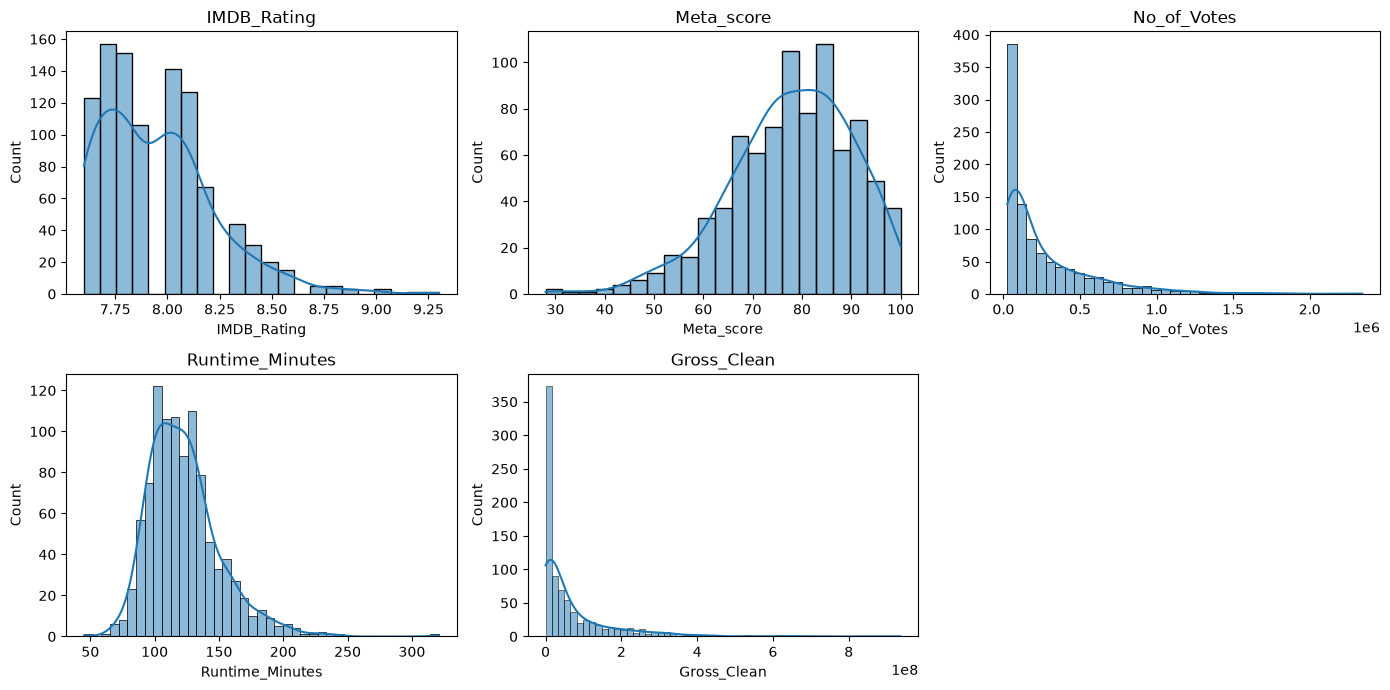

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=imdb, x=col, ax=axes[i], kde=True)
    axes[i].set_title(col)

axes[-1].axis("off")  # unused subplot
plt.tight_layout()
plt.show()

## Step 2 - Box Plots for the Key Numeric Variables

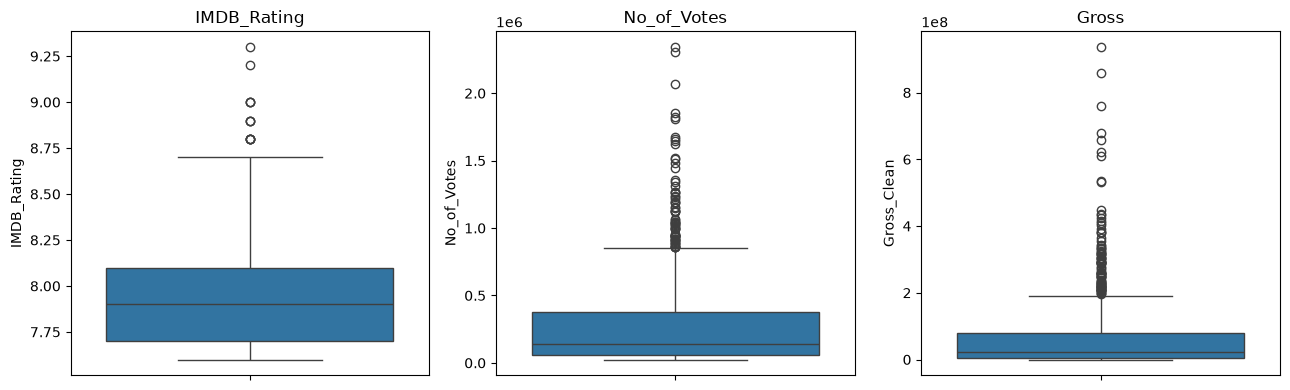

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

sns.boxplot(data=imdb, y="IMDB_Rating", ax=axes[0])
axes[0].set_title("IMDB_Rating")
sns.boxplot(data=imdb, y="No_of_Votes", ax=axes[1])
axes[1].set_title("No_of_Votes")
sns.boxplot(data=imdb, y="Gross_Clean", ax=axes[2])
axes[2].set_title("Gross")

plt.tight_layout()
plt.show()

*Visual check:* `IMDB_Rating` should look tight with few outliers (it's a curated top-1000 list, so ratings
cluster high). `No_of_Votes` and `Gross` are expected to show many points beyond the whiskers - a handful of
blockbusters dominate both.

## Step 3 - Flag Outliers with the IQR Method

In [7]:
Q1 = imdb["No_of_Votes"].quantile(0.25)
Q3 = imdb["No_of_Votes"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

vote_outliers = imdb[(imdb["No_of_Votes"] < lower_bound) | (imdb["No_of_Votes"] > upper_bound)]

print(f"IQR bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")
print(f"Flagged {len(vote_outliers)} outliers out of {len(imdb)} movies")
vote_outliers[["Series_Title", "No_of_Votes", "IMDB_Rating"]].sort_values("No_of_Votes", ascending=False).head(10)

IQR bounds: [-422,426, 852,114]
Flagged 67 outliers out of 1000 movies


,Series_Title,No_of_Votes,IMDB_Rating
0,The Shawshank Redemption,2343110,9.3
2,The Dark Knight,2303232,9.0
8,Inception,2067042,8.8
9,Fight Club,1854740,8.8
6,Pulp Fiction,1826188,8.9
11,Forrest Gump,1809221,8.8
14,The Matrix,1676426,8.7
10,The Lord of the Rings: The Fellowship of the Ring,1661481,8.8
5,The Lord of the Rings: The Return of the King,1642758,8.9
1,The Godfather,1620367,9.2


**Decision:** these aren't data-entry errors - they're genuinely massive cultural hits (think *The Dark Knight*,
*Inception*) with real vote counts, not typos. Since every entry in this dataset is already a "top 1000" film,
an unusually high vote count is a meaningful signal (popularity), not noise. **Decision: keep them**, but be
aware that any model using `No_of_Votes` as a raw feature will need a transform (e.g. log-scale) rather than
removal, since dropping them would delete some of the most famous movies in the dataset.

## Step 4 - Count Plot for Categorical Variables

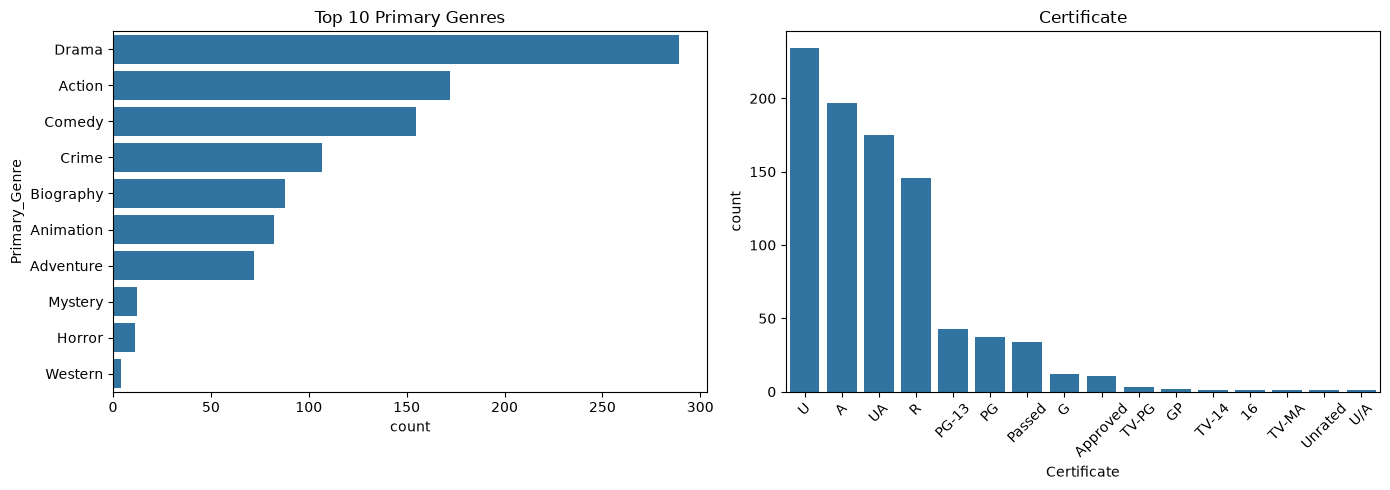

In [8]:
# Genre is multi-valued (e.g. "Crime, Drama"), so use the first-listed genre as the primary genre
imdb["Primary_Genre"] = imdb["Genre"].str.split(",").str[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_genres = imdb["Primary_Genre"].value_counts().head(10).index
sns.countplot(data=imdb[imdb["Primary_Genre"].isin(top_genres)], y="Primary_Genre",
              order=top_genres, ax=axes[0])
axes[0].set_title("Top 10 Primary Genres")

sns.countplot(data=imdb, x="Certificate",
              order=imdb["Certificate"].value_counts().index, ax=axes[1])
axes[1].set_title("Certificate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Step 5 - What the Distributions Reveal

- **IMDB_Rating:** tightly clustered near the high end with very few outliers - expected, since this dataset is
  already pre-filtered to the top 1000 films by rating.
- **No_of_Votes and Gross:** both strongly right-skewed with real, meaningful outliers - a small number of
  blockbuster films dominate. These would benefit from a log transform before use in most models.
- **Runtime_Minutes:** roughly bell-shaped around typical feature-length runtimes, with a light right tail from
  a handful of very long films (epics).
- **Primary_Genre:** shows clear class imbalance - Drama dominates the top-1000 list by a wide margin over
  genres like Film-Noir or Western, which is worth remembering if genre is ever used as a modeling feature
  (imbalanced classes need special handling).
- **Certificate:** also imbalanced, with a small number of certificate types covering most of the dataset.